In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [2]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight


In [3]:
from google.colab import drive
import zipfile, os

drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/Parkinson's Dataset Final.zip"
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

BASE = "/content/dataset/Parkinson's Dataset Final"
print("Dataset extracted to:", BASE)

print("\nBASE folders:")
print(os.listdir(BASE))


Mounted at /content/drive
Dataset extracted to: /content/dataset/Parkinson's Dataset Final

BASE folders:
['Hand Pd', 'New hand pd Dataset']


In [4]:
BASE = "/content/dataset/Parkinson's Dataset Final"

HANDPD_ROOT = os.path.join(BASE, "Hand Pd")
NEWHANDPD_ROOT = os.path.join(BASE, "New hand pd Dataset")

print("HANDPD_ROOT:", HANDPD_ROOT)
print("NEWHANDPD_ROOT:", NEWHANDPD_ROOT)

print("\nHandPD folders:", os.listdir(HANDPD_ROOT))
print("NewHandPD folders:", os.listdir(NEWHANDPD_ROOT))


HANDPD_ROOT: /content/dataset/Parkinson's Dataset Final/Hand Pd
NEWHANDPD_ROOT: /content/dataset/Parkinson's Dataset Final/New hand pd Dataset

HandPD folders: ['Meander_HandPD', 'Spiral_HandPD']
NewHandPD folders: ['Healthy', "Parkinson's"]


In [5]:
IMG_SIZE = 224

def preprocess_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None

    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    img = cv2.GaussianBlur(img, (3, 3), 0)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    img = img.astype(np.float32) / 255.0

    img = np.expand_dims(img, axis=-1)
    return img


def load_folder(folder_path, label, X, y):
    valid_ext = (".jpg", ".jpeg", ".png", ".bmp")
    count = 0

    for root, _, files in os.walk(folder_path):
        for f in files:
            if f.lower().endswith(valid_ext):
                path = os.path.join(root, f)
                img = preprocess_image(path)
                if img is not None:
                    X.append(img)
                    y.append(label)
                    count += 1

    return count


In [7]:
X, y = [], []

handpd_total = 0

for sub in ["Spiral_HandPD", "Meander_HandPD"]:
    sub_path = os.path.join(HANDPD_ROOT, sub)

    healthy_path = os.path.join(sub_path, "healthy")
    parkinson_path = os.path.join(sub_path, "parkinson")

    c1 = load_folder(healthy_path, 0, X, y)
    c2 = load_folder(parkinson_path, 1, X, y)

    print(f"[HandPD - {sub}] Healthy: {c1} | Parkinson: {c2}")
    handpd_total += (c1 + c2)


new_total = 0

healthy_main = os.path.join(NEWHANDPD_ROOT, "Healthy")
parkinson_main = os.path.join(NEWHANDPD_ROOT, "Parkinson's")

c3 = load_folder(healthy_main, 0, X, y)
c4 = load_folder(parkinson_main, 1, X, y)

print(f"\n[NewHandPD] Healthy: {c3} | Parkinson: {c4}")
new_total += (c3 + c4)

print("\n")
print("TOTAL HandPD images:", handpd_total)
print("TOTAL NewHandPD images:", new_total)
print("TOTAL Combined images:", len(X))
print("")


[HandPD - Spiral_HandPD] Healthy: 144 | Parkinson: 296
[HandPD - Meander_HandPD] Healthy: 72 | Parkinson: 296

[NewHandPD] Healthy: 233 | Parkinson: 279


TOTAL HandPD images: 808
TOTAL NewHandPD images: 512
TOTAL Combined images: 1320



In [8]:
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

print("Healthy count:", np.sum(y == 0))
print("Parkinson count:", np.sum(y == 1))


Final X shape: (1320, 224, 224, 1)
Final y shape: (1320,)
Healthy count: 449
Parkinson count: 871


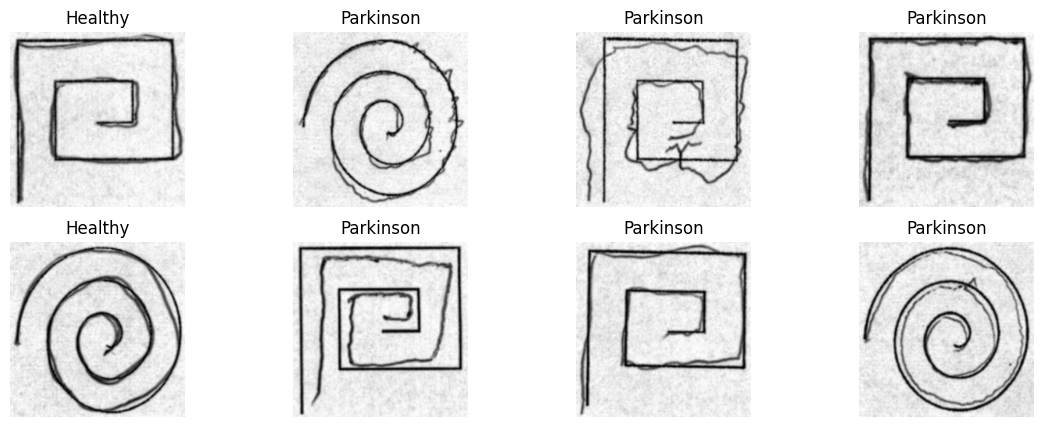

In [9]:
def show_samples(X, y, n=8):
    plt.figure(figsize=(14, 5))
    idxs = np.random.choice(len(X), n, replace=False)

    for i, idx in enumerate(idxs):
        plt.subplot(2, n//2, i+1)
        plt.imshow(X[idx].squeeze(), cmap="gray")
        plt.title("Healthy" if y[idx] == 0 else "Parkinson")
        plt.axis("off")
    plt.show()

show_samples(X, y, n=8)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTrain Healthy:", np.sum(y_train==0), "Train Parkinson:", np.sum(y_train==1))
print("Test Healthy:", np.sum(y_test==0), "Test Parkinson:", np.sum(y_test==1))


Train shape: (990, 224, 224, 1) (990,)
Test shape: (330, 224, 224, 1) (330,)

Train Healthy: 337 Train Parkinson: 653
Test Healthy: 112 Test Parkinson: 218


In [11]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class Weights:", class_weights_dict)


Class Weights: {0: np.float64(1.4688427299703264), 1: np.float64(0.7580398162327718)}


In [12]:
import tensorflow as tf
from tensorflow.keras import layers, Model


In [13]:
class PatchEmbedding(layers.Layer):
    def __init__(self, patch_size=16, embed_dim=526, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.proj = layers.Conv2D(embed_dim, kernel_size=patch_size, strides=patch_size, padding="valid")

    def call(self, x):
        x = self.proj(x)                       # (B, 14, 14, embed_dim)
        x = tf.reshape(x, [tf.shape(x)[0], -1, self.embed_dim])  # (B, 196, embed_dim)
        return x


In [14]:
class PositionalEncoding(layers.Layer):
    def __init__(self, num_patches, dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.dim = dim

    def build(self, input_shape):
        self.pos_embedding = self.add_weight(
            name="pos_embedding",
            shape=(1, self.num_patches, self.dim),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        return x + self.pos_embedding


In [15]:
class TransformerBlock(layers.Layer):
    def __init__(self, dim, num_heads, mlp_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)

        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=dim//num_heads, dropout=dropout)
        self.drop1 = layers.Dropout(dropout)

        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = tf.keras.Sequential([
            layers.Dense(mlp_dim, activation="gelu"),
            layers.Dropout(dropout),
            layers.Dense(dim),
            layers.Dropout(dropout)
        ])

    def call(self, x, training=False):
        # Self-attention
        attn_out = self.attn(self.norm1(x), self.norm1(x), training=training)
        x = x + self.drop1(attn_out, training=training)

        # Feedforward
        mlp_out = self.mlp(self.norm2(x), training=training)
        x = x + mlp_out
        return x


In [16]:
def build_custom_vit_feature_extractor():
    inputs = layers.Input(shape=(224, 224, 1))

    x = PatchEmbedding(patch_size=16, embed_dim=526, name="patch_embedding")(inputs)
    x = PositionalEncoding(num_patches=196, dim=526, name="positional_encoding")(x)
    x = TransformerBlock(dim=526, num_heads=2, mlp_dim=1024, dropout=0.1, name="transformer_block")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_2")(x)
    x = layers.Dense(256, name="dense_2")(x)
    x = TransformerBlock(dim=256, num_heads=2, mlp_dim=512, dropout=0.1, name="transformer_block_1")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_5")(x)
    x = layers.Dense(128, name="dense_5")(x)
    x = TransformerBlock(dim=128, num_heads=2, mlp_dim=256, dropout=0.1, name="transformer_block_2")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_8")(x)
    x = layers.Dense(64, name="dense_8")(x)
    x = TransformerBlock(dim=64, num_heads=2, mlp_dim=128, dropout=0.1, name="transformer_block_3")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_11")(x)
    x = layers.Dense(32, name="dense_11")(x)
    x = TransformerBlock(dim=32, num_heads=2, mlp_dim=64, dropout=0.1, name="transformer_block_4")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_14")(x)
    x = layers.Dense(16, name="dense_14")(x)
    x = TransformerBlock(dim=16, num_heads=2, mlp_dim=32, dropout=0.1, name="transformer_block_5")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_17")(x)
    x = layers.Dense(8, name="dense_17")(x)
    x = TransformerBlock(dim=8, num_heads=2, mlp_dim=16, dropout=0.1, name="transformer_block_6")(x)
    x = layers.LayerNormalization(epsilon=1e-6, name="layer_normalization_20")(x)
    x = layers.Dense(4, name="dense_20")(x)
    x = TransformerBlock(dim=4, num_heads=1, mlp_dim=8, dropout=0.1, name="transformer_block_7")(x)

    features = layers.GlobalAveragePooling1D(name="vit_final_feature")(x)

    return Model(inputs, features, name="Custom_ViT_Feature_Extractor")


In [17]:
vit_extractor = build_custom_vit_feature_extractor()
vit_extractor.summary()


Model: "Custom_ViT_Feature_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_embedding                 │ (None, None, 526)      │       135,182 │
│ (PatchEmbedding)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 196, 526)       │       103,096 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 196, 526)       │     2,189,710 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 196, 526)       │         1,052 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 196, 256)       │       134,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 196, 256)       │       527,104 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 196, 256)       │           512 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 196, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 196, 128)       │       132,480 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_8           │ (None, 196, 128)       │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 196, 64)        │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 196, 64)        │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_11          │ (None, 196, 64)        │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 196, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ (None, 196, 32)        │         8,544 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_14          │ (None, 196, 32)        │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 196, 16)        │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 196, 16)        │         2,22

 Total params: 3,313,488 (12.64 MB)

 Trainable params: 3,313,488 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
inputs = layers.Input(shape=(224, 224, 1))
feat = vit_extractor(inputs)

x = layers.Dense(32, activation="relu")(feat)
x = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation="sigmoid")(x)

probe_model = Model(inputs, out, name="MiniViT_Probe_Model")
probe_model.summary()


Model: "MiniViT_Probe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Custom_ViT_Feature_Extractor    │ (None, 4)              │     3,313,488 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,313,681 (12.64 MB)

 Trainable params: 3,313,681 (12.64 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
probe_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "BEST_MINIVIT_PROBE.keras",
    monitor="val_loss",
    save_best_only=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-7
)

history_probe = probe_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    class_weight=class_weights_dict,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)


Epoch 1/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.4004 - loss: 0.7315 - val_accuracy: 0.6606 - val_loss: 0.6889 - learning_rate: 1.0000e-04
Epoch 2/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.5133 - loss: 0.7178 - val_accuracy: 0.3394 - val_loss: 0.7017 - learning_rate: 1.0000e-04
Epoch 3/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.4505 - loss: 0.6930 - val_accuracy: 0.3394 - val_loss: 0.7046 - learning_rate: 1.0000e-04
Epoch 4/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.4781 - loss: 0.6929 - val_accuracy: 0.3394 - val_loss: 0.7022 - learning_rate: 1.0000e-04
Epoch 5/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.4449 - loss: 0.6915 - val_accuracy: 0.3394 - val_loss: 0.6945 - learning_rate: 5.0000e-05
Epoch 6/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.4108 - loss: 0.7123 - val_accuracy: 0.6606 - val_loss: 0.6797 - learning_rate: 5.0000e-05
Epoch 7/40
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.5284 

In [20]:
import numpy as np

print("Train label counts:", np.bincount(y_train))
print("Test  label counts:", np.bincount(y_test))

print("Train ratio Parkinson:", np.mean(y_train))
print("Test ratio Parkinson :", np.mean(y_test))


Train label counts: [337 653]
Test  label counts: [112 218]
Train ratio Parkinson: 0.6595959595959596
Test ratio Parkinson : 0.6606060606060606


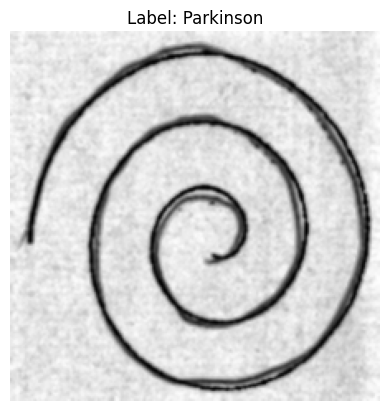

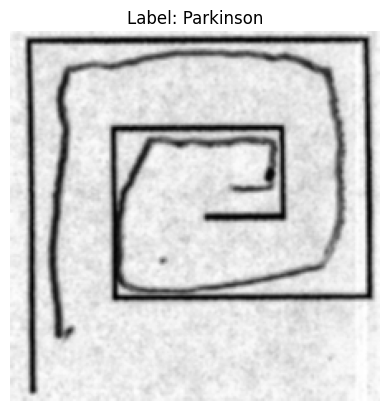

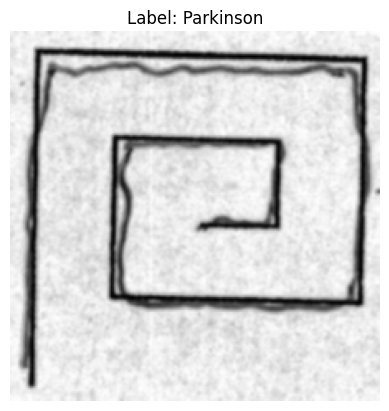

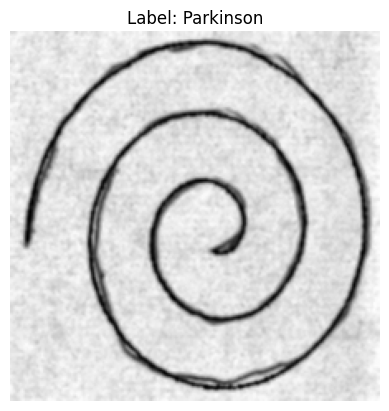

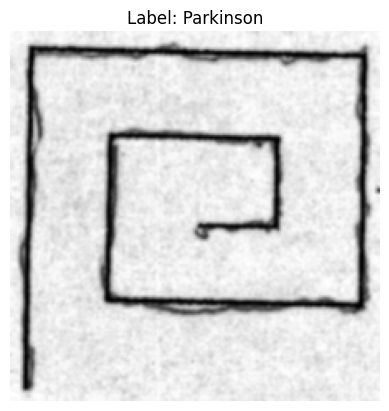

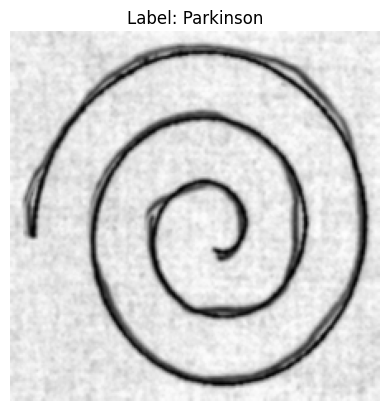

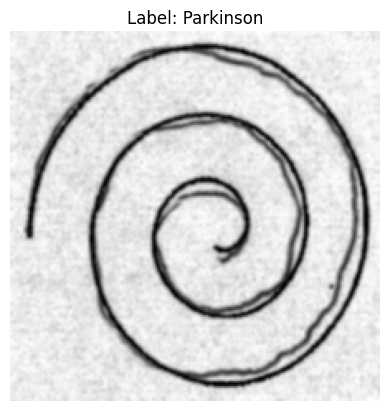

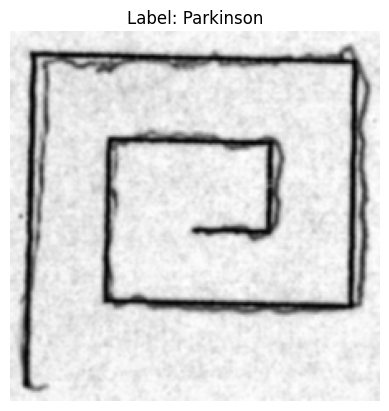

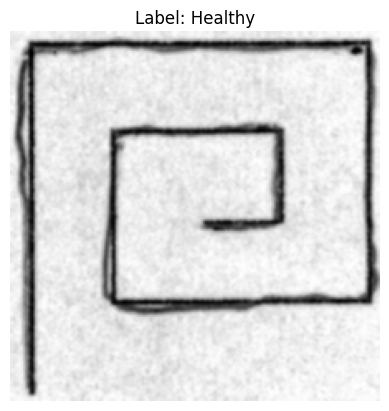

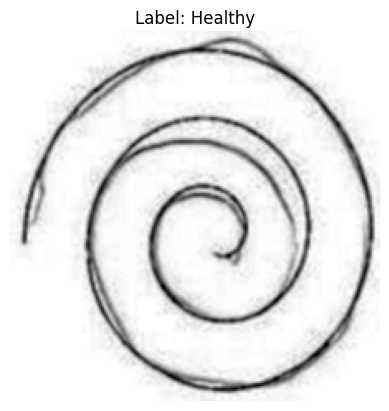

In [21]:
import matplotlib.pyplot as plt
import random

for i in range(10):
    idx = random.randint(0, len(X_train)-1)
    img = X_train[idx].squeeze()
    label = y_train[idx]

    plt.imshow(img, cmap="gray")
    plt.title("Label: " + ("Parkinson" if label==1 else "Healthy"))
    plt.axis("off")
    plt.show()


In [22]:
print(np.unique(y, return_counts=True))


(array([0, 1], dtype=int32), array([449, 871]))
